## Multi-Slice MRI Reconstruction
This notebook aims to reconstruct multiple MRI image slices from undersampled k-space data and compares several reconstruction strategies on a shared train/validation/test split.

## Main Goals
1. Build a multi-image dataset from one MRI series
2. Learn shared kernel hyperparameters across training slices
3. Evaluate the kernel method on held-out test slices
4. Compare against a zero-filled FFT baseline
5. Train a residual CNN correctors that refine either the kernel reconstruction or the zero-filled baseline

## Overall Setup
- Load and preprocess one MRI series
- Create an undersampling mask
- Tune kernel hyperparameters on training slices
- Reconstruct held-out slices with optimized hyperparameters
- Train neural residual models on top of those reconstructions

tcia_utils nbia is the interface to the cancer imaging archive so theres available datasets we can use

In [ ]:
!pip install tcia_utils pydicom torch matplotlib numpy torchmetrics scikit-optimize

import torch
import numpy as np
import pydicom
import matplotlib.pyplot as plt
import os
from tcia_utils import nbia
import math
import random
from dataclasses import dataclass
import torch.nn as nn
import torch.nn.functional as F
import shutil
import pandas as pd

import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-optimize"])
from skopt import gp_minimize
from skopt.space import Real, Integer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.3 MB/s eta 0:00:00


In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# Load Data & Build a Multi-Slice Dataset

Download one full series, sort slices into anatomical order, and randomly sample slices from the middle of the scan stack.

In [ ]:
# lists candidate series so you ca pick which scan to use
data = nbia.getSeries(collection="UPENN-GBM")
if data is None:
    raise RuntimeError("UPENN-GBM returned no data.")
print(f"'UPENN-GBM' returned {len(data)} series")

for i, s in enumerate(data[:10]):
  desc = s.get("SeriesDescription")
  nimg = s.get("ImageCount")
  print(f"Index {i}: {desc} | Images: {nimg}")

if os.path.exists("./brain_mri_rebuild"):
  shutil.rmtree("./brain_mri_rebuild")
os.mkdir("./brain_mri_rebuild")

'UPENN-GBM' returned 3680 series
Index 0: AXIAL 3D GAD: Processed_CaPTk | Images: 120
Index 1: AX FLAIR: Processed_CaPTk | Images: 32
Index 2: AX T1 PRE : Processed_CaPTk | Images: 32
Index 3: AX T2 : Processed_CaPTk | Images: 32
Index 4: AX T2 : Processed_CaPTk | Images: 32
Index 5: AX T1 MPRAGE ISOTROPIC: Processed_CaPTk | Images: 192
Index 6: AXIAL FLAIR : Processed_CaPTk | Images: 60
Index 7: AX T1 PRE : Processed_CaPTk | Images: 32
Index 8: ep2d_perf 12 CC BOLUS | Images: 900
Index 9: ep2d_perf 12 CC BOLUS | Images: 900


In [ ]:
# download one full series
nbia.downloadSeries(data[5:6], number=1, path="./brain_mri_rebuild")

# collect DICOM files
dcm_files = []
for root, dirs, files in os.walk("./brain_mri_rebuild"):
  for f in files:
    if f.lower().endswith(".dcm"):
      dcm_files.append(os.path.join(root, f))

# load datasets
datasets = [pydicom.dcmread(f) for f in dcm_files]

def slice_sort_key(ds):
  if hasattr(ds, "InstanceNumber"):
    return float(ds.InstanceNumber)
  elif hasattr(ds, "ImagePositionPatient"):
    return float(ds.ImagePositionPatient[2])
  else:
    return 0.0

datasets.sort(key=slice_sort_key)

print("Number of slices in full series:", len(datasets))
print("First slice instance number:", getattr(datasets[0], "InstanceNumber", "NA"))
print("Middle slice instance number:", getattr(datasets[len(datasets)//2], "InstanceNumber", "NA"))
print("Last slice instance number:", getattr(datasets[-1], "InstanceNumber", "NA"))

Number of slices in full series: 192
First slice instance number: 1
Middle slice instance number: 97
Last slice instance number: 192


In [ ]:
# determine number of slices to randomly sample
num_slices = 96

# sample randomly from the middle 80% of slices to avoid nearly empty top/bottom slices
start = int(0.1 * len(datasets))
end = int(0.9 * len(datasets))

available_indices = list(range(start, end))
sampled_indices = sorted(random.sample(available_indices, num_slices))
datasets = [datasets[i] for i in sampled_indices]

print("Randomly sampled slice indices", sampled_indices)
print("Number of sampled slices:", len(datasets))

Randomly sampled slice indices [20, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 34, 36, 38, 39, 40, 41, 42, 43, 45, 46, 47, 48, 50, 52, 53, 54, 55, 56, 59, 60, 62, 63, 64, 65, 66, 67, 69, 70, 74, 75, 76, 77, 78, 81, 84, 87, 89, 90, 92, 96, 97, 98, 99, 100, 101, 103, 104, 106, 108, 109, 111, 112, 116, 118, 121, 122, 123, 124, 126, 127, 129, 133, 134, 135, 136, 137, 139, 141, 145, 146, 147, 148, 152, 153, 156, 157, 158, 160, 161, 162, 165, 166, 169, 170, 171]
Number of sampled slices: 96


## Preprocessing Results
Each DICOM slice is converted into a normalized grayscale tensor and resized to a fixed resolution.

Output per slice: a tensor of shape 1 x 256 x 256 with values approximately in [0,1].

We sampled from the middle slices because the top and bottom slices in an MRI often contain much less structure. Sampling from the middle gives slices with more anatomical content for training and testing.

### Slice preprocessing

Converts each DICOM file into a tensor by normalizing to [0,1] and resizing to 256 x 256

In [ ]:
def dicom_to_tensor(ds, out_size=(256,256)):
  arr = ds.pixel_array.astype(np.float32)

  slope = float(getattr(ds, "RescaleSlope", 1.0))
  intercept = float(getattr(ds, "RescaleIntercept", 0.0))
  arr = arr * slope + intercept

  p_low, p_high = np.percentile(arr, (1, 99))
  arr = np.clip(arr, p_low, p_high)
  arr = (arr - p_low) / (p_high - p_low + 1e-12)

  t = torch.tensor(arr, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
  t = F.interpolate(t, size=out_size, mode="bilinear", align_corners=False)
  return t.squeeze(0) # [1, H, W]

target_images = torch.stack([dicom_to_tensor(ds) for ds in datasets], dim=0) # [N, 1, H, W]
N, C, H, W = target_images.shape

print("target_images shape:", target_images.shape)
print("dtype:", target_images.dtype)

target_images shape: torch.Size([96, 1, 256, 256])
dtype: torch.float32


# Kernel Reconstruction Setup

Here we define the pieces needed for kernel reconstruction:
- A TV regularizer that encourages smoothness
- A kernel basis over the image grid

Right now, the basis is Gaussian and shared across slices through common hyperparamters such as kernel width and number of kernels. The Gaussian kernels are placed on a grid of centers across the image domain.

In [ ]:
def tv_loss(x, eps=1e-6):
    dx = x[1:, :] - x[:-1, :]      # [255, 256]
    dy = x[:, 1:] - x[:, :-1]      # [256, 255]

    dx = dx[:, :-1]                # → [255, 255]
    dy = dy[:-1, :]                # → [255, 255]

    return torch.mean(torch.sqrt(dx**2 + dy**2 + eps))

In [ ]:
# GAUSSIAN
def create_kernel_basis(grid_size=256, num_kernels=1600, sigma=8.0):
  side = int(np.sqrt(num_kernels))
  assert side * side == num_kernels, "num_kernels must be a perfect square"

  x = torch.linspace(0, grid_size - 1, grid_size)
  y = torch.linspace(0, grid_size - 1, grid_size)
  grid_x, grid_y = torch.meshgrid(x, y, indexing="ij")

  coords = torch.linspace(0, grid_size - 1, side)
  centers_x, centers_y = torch.meshgrid(coords, coords, indexing="ij")
  centers_x = centers_x.flatten()
  centers_y = centers_y.flatten()

  basis = []
  for i in range(num_kernels):
    dist_sq = (grid_x -centers_x[i])**2 + (grid_y - centers_y[i])**2
    kernel = torch.exp(-dist_sq / (2 * sigma**2)) # Gaussian
    basis.append(kernel.flatten())

  Phi = torch.stack(basis, dim=1)

  Phi = Phi / (torch.norm(Phi, dim=0, keepdim=True) + 1e-12)
  return Phi

In [ ]:
BEST_SIGMA = 2.5
BEST_NUM_KERNELS = 3844
BEST_LAMBDA_TV = 0.0

## Success Metrics
The performance of the image reconstruction is evaluated using:
*   **Mean Squared Error (MSE):** Measures the average squared difference between the reconstructed image and the original target image.
*   **Peak Signal-to-Noise Ratio (PSNR):** A common metric for image quality, providing a quantitative measure of reconstruction fidelity. Higher PSNR values indicate better reconstruction quality.
* **SSIM** that captures structural similarity

## Resource Monitoring

The cells that take long were noted above. If memory becomes an issue, reduce the number of slices, number of kernels, or training epochs.





# Residual CNN with Kernel Reconstructions

This section trains a CNN to predict a residual correction to the kernel reconstruction. The corrected image is then projected back to match the observed k-space values using a data consistency step.

Overall:
- the kernel method provides a structured warm start
- the CNN fills in image-domain details
- data consistency prevents the network from changing measurements that were actually observed



In [ ]:
# train / validation / test split over slices
num_images = target_images.shape[0]
all_indices = list(range(num_images))
rng = np.random.default_rng(seed)
rng.shuffle(all_indices)

train_end = int(0.70 * num_images)
val_end = int(0.85 * num_images)

train_indices = all_indices[:train_end]
val_indices = all_indices[train_end:val_end]
test_indices = all_indices[val_end:]

# TEMPORARY: smaller subsets so tuning finishes
train_indices = train_indices[:8]
val_indices = val_indices[:4]
test_indices = test_indices[:4]

print(f"num_images = {num_images}")
print(f"train / val / test = {len(train_indices)} / {len(val_indices)} / {len(test_indices)}")

num_images = 96
train / val / test = 8 / 4 / 4


In [ ]:
# trims the number of slices used by the kernel-residual CNN
# used to keep training doable
train_indices = train_indices[:8]
val_indices   = val_indices[:3]
test_indices  = test_indices[:3]

print("Train:", train_indices)
print("Val:", val_indices)
print("Test:", test_indices)

Train: [57, 21, 75, 18, 33, 40, 93, 27]
Val: [16, 44, 78]
Test: [41, 22, 19]


In [ ]:
from pydicom.fileutil import reset_buffer_position
# Week 4 hyperparameter tuning idea to training set
class MultiSliceKernelOptimizer:
  def __init__(self, target_images, mask, device="cuda"):
    self.target_images = target_images.to(device)
    self.mask = mask.to(device)
    self.device = device
    self.grid_size = target_images.shape[-1]

  def _coerce_num_kernels(self, num_kernels):
    # create_kernel_basis uses a square grid of centers, so move to nearest square
    side = max(4, int(round(np.sqrt(int(num_kernels)))))
    return side * side

  def reconstruct_single_slice(self, target_image, sigma, num_kernels, lambda_tv=1e-14, max_iter=500, lr=0.01, return_history=False):
    target_image = target_image.to(device)
    num_kernels = self._coerce_num_kernels(num_kernels)

    Phi = create_kernel_basis(
        grid_size=self.grid_size,
        num_kernels=num_kernels,
        sigma=float(sigma)
    ).to(self.device).float()

    c = (torch.randn(num_kernels, device=self.device) * 0.01).requires_grad_(True)
    optimizer = torch.optim.Adam([c], lr=lr)

    k_full = torch.fft.fftshift(torch.fft.fft2(target_image))
    y_obs = k_full * self.mask

    loss_history = []
    for epoch in range(max_iter):
      optimizer.zero_grad()

      x_recon = (Phi @ c).reshape(self.grid_size, self.grid_size)
      k_recon = torch.fft.fftshift(torch.fft.fft2(x_recon))
      y_recon = k_recon * self.mask

      data_loss = torch.mean(torch.abs(y_recon - y_obs) ** 2)
      tv = tv_loss(x_recon)
      loss = data_loss + float(lambda_tv) * tv

      loss.backward()
      optimizer.step()

      if return_history:
        loss_history.append(loss.item())

    with torch.no_grad():
      final_recon = (Phi @ c).reshape(self.grid_size, self.grid_size)
      final_recon = torch.clamp(final_recon, 0.0, 1.0)
      mse = torch.nn.functional.mse_loss(final_recon, target_image)
      psnr = 10 * torch.log10(1.0 / (mse + 1e-12))

    out = {
        "num_kernels": num_kernels,
        "mse": mse.item(),
        "psnr": psnr.item(),
        "reconstruction": final_recon.detach()
    }
    if return_history:
      out["loss_history"] = loss_history
    return out

  def dataset_objective(self, indices, sigma, num_kernels, lambda_tv=1e-4, max_iter=500, lr=0.01):
    mses, psnrs = [], []
    for idx in indices:
      img = self.target_images[idx, 0]
      out = self.reconstruct_single_slice(
          img,
          sigma=sigma,
          num_kernels=num_kernels,
          lambda_tv=lambda_tv,
          max_iter=max_iter,
          lr=lr,
          return_history=False
      )
      mses.append(out["mse"])
      psnrs.append(out["psnr"])

    return {
        "mean_mse": float(np.mean(mses)),
        "mean_psnr": float(np.mean(psnrs))
    }

  def bayes_opt(self, train_indices, n_trials=15, max_iter=400, lr=0.01):
    def objective(params):
      sigma, num_kernels, lambda_tv = params
      stats = self.dataset_objective(
          train_indices,
          sigma=sigma,
          num_kernels=int(num_kernels),
          lambda_tv=lambda_tv,
          max_iter=max_iter,
          lr=lr
      )
      print(
          f"trial -> sigma={sigma:.4f}, "
          f"num_kernels~={int(num_kernels)}, "
          f"lambda_tv={lambda_tv:.2e}, "
          f"train_mse={stats["mean_mse"]:.6f}, "
          f"train_psnr={stats["mean_psnr"]:.3f} dB"
      )
      return stats["mean_mse"]

    space = [
        Real(3.0, 15.0, prior="log-uniform", name="sigma"),
        Integer(1024, 4096, name="num_kernels"),
        Real(1e-8, 1e-4, prior="log-uniform", name="lambda_tv")
    ]

    result = gp_minimize(
        objective,
        space,
        n_calls=n_trials,
        n_initial_points=3,
        random_state=seed
    )

    best_sigma = float(result.x[0])
    best_num_kernels = self._coerce_num_kernels(int(result.x[1]))
    best_lambda_tv = float(result.x[2])

    return {
        "result": result,
        "best_sigma": best_sigma,
        "best_num_kernels": best_num_kernels,
        "best_lambda_tv": best_lambda_tv
    }

In [ ]:
# same mask for all slices to make fair hyperparameter comparisons
def create_variable_density_mask(H, W, center_fraction=0.08, accel=4.0, seed=42):
  """
  2D variable-density mask:
  - fully samples a small low-frequency center
  - samples outer k-space with radius-dependent probability
  """
  yy, xx = torch.meshgrid(
      torch.linspace(-1.0, 1.0, H),
      torch.linspace(-1.0, 1.0, W),
      indexing="ij"
  )
  rr = torch.sqrt(xx**2 + yy **2)

  prob = 1.0 / accel + (1.0 - 1.0 / accel) * torch.exp(-6.0 * rr**2)

  center_h = max(1, int(H*center_fraction))
  center_w = max(1, int(W*center_fraction))
  h0 = H // 2 - center_h // 2
  h1 = h0 + center_h
  w0 = W // 2 - center_w // 2
  w1 = w0 + center_w

  g = torch.Generator(device="cpu")
  g.manual_seed(seed)
  random_field = torch.rand((H, W), generator=g)

  mask_real = (random_field < prob).float()
  mask_real[h0:h1, w0:w1] = 1.0
  return mask_real

mask = create_variable_density_mask(H, W, center_fraction=0.08, accel=4.0, seed=seed).to(device)
mask = mask.to(torch.complex64)

representative_test_idx = test_indices[0]
target_image = target_images[representative_test_idx, 0].to(device)

k_full = torch.fft.fftshift(torch.fft.fft2(target_image))
y_obs = k_full * mask

print(f"Representative held-out test slice: {representative_test_idx}")
print(f"k_full shape: {k_full.shape}")
print(f"mask shape: {mask.shape}")
print(f"y_obs shape: {y_obs.shape}")

def ifft2(k_space_data):
  """
  Applies 2D inverse Fast Fourier Transform and returns the real part.
  """
  return torch.fft.ifft2(k_space_data).real

Representative held-out test slice: 41
k_full shape: torch.Size([256, 256])
mask shape: torch.Size([256, 256])
y_obs shape: torch.Size([256, 256])


For each slice in the CNN subset, we first compute the kernel reconstruction that will serve as the model input.

**Note**: this can be slow because it reconstructs many slices before training even begins

In [ ]:
 # build kernel reconstruction only for slices used by CNN
needed_indices = sorted(set(train_indices + val_indices + test_indices))

kernel_recon_dict = {}

kernel_opt = MultiSliceKernelOptimizer(target_images, mask, device=device)

for count, i in enumerate(needed_indices):
  print(f"Reconstructing slice {i} ({count+1}/{len(needed_indices)})")

  out = kernel_opt.reconstruct_single_slice(
      target_images[i,0],
      sigma=BEST_SIGMA,
      num_kernels=BEST_NUM_KERNELS,
      lambda_tv=BEST_LAMBDA_TV,
      max_iter=100,
      lr=0.01,
      return_history=False
  )

  kernel_recon_dict[i] = out["reconstruction"].detach().cpu().float().clamp(0,1)

Reconstructing slice 16 (1/14)
Reconstructing slice 18 (2/14)
Reconstructing slice 19 (3/14)
Reconstructing slice 21 (4/14)
Reconstructing slice 22 (5/14)
Reconstructing slice 27 (6/14)
Reconstructing slice 33 (7/14)
Reconstructing slice 40 (8/14)
Reconstructing slice 41 (9/14)
Reconstructing slice 44 (10/14)
Reconstructing slice 57 (11/14)
Reconstructing slice 75 (12/14)
Reconstructing slice 78 (13/14)
Reconstructing slice 93 (14/14)


In [ ]:
# train / val / test tensors for kernel residual learning

x_train = torch.stack([kernel_recon_dict[i].unsqueeze(0) for i in train_indices], dim=0)
y_train = target_images[train_indices].cpu().float()

x_val = torch.stack([kernel_recon_dict[i].unsqueeze(0) for i in val_indices], dim=0)
y_val = target_images[val_indices].cpu().float()

x_test = torch.stack([kernel_recon_dict[i].unsqueeze(0) for i in test_indices], dim=0)
y_test = target_images[test_indices].cpu().float()

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_val: ", x_val.shape, "y_val: ", y_val.shape)
print("x_test: ", x_test.shape, "y_test: ", y_test.shape)

x_train: torch.Size([8, 1, 256, 256]) y_train: torch.Size([8, 1, 256, 256])
x_val:  torch.Size([3, 1, 256, 256]) y_val:  torch.Size([3, 1, 256, 256])
x_test:  torch.Size([3, 1, 256, 256]) y_test:  torch.Size([3, 1, 256, 256])


In [ ]:
from torch.utils.data import Dataset, DataLoader

class PairDataset(Dataset):
  def __init__(self, x, y):
    self.x = x.float()
    self.y = y.float()

  def __len__(self):
    return self.x.shape[0]

  def __getitem__(self, i):
    return self.x[i], self.y[i]

train_loader = DataLoader(PairDataset(x_train, y_train), batch_size=4, shuffle=True)
val_loader = DataLoader(PairDataset(x_val, y_val), batch_size=4, shuffle=False)
test_loader = DataLoader(PairDataset(x_test, y_test), batch_size=4, shuffle=False)

This function replaces the reconstructed k-space values at observed locations with the actual measured values, so the network can't overwrite "real" k-space data.

In [ ]:
def data_consistency(x, y_obs, mask):
  """
  x: [B, 1, H, W] real image
  y_obs: [B, 1, H, W] complex undersampled k-space
  mask: [H, W] or [1, H, W] real/bool sampling mask
  """
  k = torch.fft.fftshift(torch.fft.fft2(x, dim=(-2, -1)), dim=(-2, -1))

  # expand mask to [B, 1, H, W]
  if mask.dim() == 2:
    mask_exp = mask.unsqueeze(0).unsqueeze(0)
  elif mask.dim() == 3:
    mask_exp = mask.unsqueeze(0)
  else:
    mask_exp = mask

  mask_exp = mask_exp.to(x.device)

  # keep measured k-space where mask=1, use CNN output where mask=0
  k_dc = (1.0 - mask_exp) * k + mask_exp * y_obs

  x_dc = torch.fft.ifft2(torch.fft.ifftshift(k_dc, dim=(-2,-1)), dim=(-2,-1))
  x_dc = torch.abs(x_dc)
  return x_dc

In [ ]:
class KernelResidualCNN_DC(nn.Module):
  def __init__(self, ch=64):
    super().__init__()
    self.net = nn.Sequential(
        nn.Conv2d(1, ch, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(ch, ch, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(ch, ch, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(ch, 1, 3, padding=1)
    )

  def forward(self, x_kernel, y_obs, mask):
    residual = self.net(x_kernel)
    x_cnn = x_kernel + residual
    x_dc = data_consistency(x_cnn, y_obs, mask)
    return torch.clamp(x_dc, 0.0, 1.0)

model_kernel = KernelResidualCNN_DC(ch=64).to(device)
print(model_kernel)

KernelResidualCNN_DC(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)


In [ ]:
def compute_psnr(pred, target):
  mse = F.mse_loss(pred, target)
  return 10 * torch.log10(1.0 / (mse + 1e-12))

In [ ]:
_ssim_window_cache = {}

def gaussian_window(window_size=11, sigma=1.5, channels=1, device="cpu", dtype=torch.float32):
  coords = torch.arange(window_size, device=device, dtype=dtype) - window_size // 2
  g = torch.exp(-(coords ** 2) / (2 * sigma**2))
  g = g / g.sum()
  window_2d = torch.outer(g, g)
  window_2d = window_2d / window_2d.sum()
  window = window_2d.expand(channels, 1, window_size, window_size).contiguous()
  return window

def compute_ssim(x, y, data_range=1.0, window_size=11, sigma=1.5, eps=1e-12):
  """
  x, y: [B, 1, H, W]
  returns: scalar tensor
  """
  x = x.float()
  y = y.float()

  channels = x.size(1)

  key = (window_size, sigma, channels, str(x.device), x.dtype)
  if key not in _ssim_window_cache:
    _ssim_window_cache[key] = gaussian_window(window_size, sigma, channels, x.device, x.dtype)
  window = _ssim_window_cache[key]

  mu_x = F.conv2d(x, window, padding=window_size // 2, groups=channels)
  mu_y = F.conv2d(y, window, padding=window_size // 2, groups=channels)

  mu_x2 = mu_x * mu_x
  mu_y2 = mu_y * mu_y
  mu_xy = mu_x * mu_y

  sigma_x2 = F.conv2d(x * x, window, padding=window_size // 2, groups=channels) - mu_x2
  sigma_y2 = F.conv2d(y * y, window, padding=window_size // 2, groups=channels) - mu_y2
  sigma_xy = F.conv2d(x * y, window, padding=window_size // 2, groups=channels) - mu_xy

  C1 = (0.01 * data_range) ** 2
  C2 = (0.03 * data_range) ** 2

  ssim_map = ((2 * mu_xy + C1) * (2 * sigma_xy + C2)) / (
      (mu_x2 + mu_y2 + C1) * (sigma_x2 + sigma_y2 + C2) + eps
  )

  return ssim_map.mean()

**Note**: this can also be long depending on GPU / CPU choice

In [ ]:
# train kernel residual CNN with data consistency
optimizer = torch.optim.Adam(model_kernel.parameters(), lr=1e-3)
num_epochs = 50

train_loss_history = []
val_loss_history = []
train_psnr_history = []
val_psnr_history = []
train_ssim_history = []
val_ssim_history = []

mask_t = mask.to(device)

for epoch in range(num_epochs):
  model_kernel.train()
  running_loss = 0.0
  running_psnr = 0.0
  running_ssim = 0.0
  n_train = 0

  for xb, yb in train_loader:
    xb = xb.to(device) # kernel baseline
    yb = yb.to(device) # ground truth

    # simulate observed undersampled k-space from the target
    k_full = torch.fft.fftshift(torch.fft.fft2(yb, dim=(-2,-1)), dim=(-2,-1))
    if mask_t.dim() == 2:
      y_obs = k_full * mask_t.unsqueeze(0).unsqueeze(0)
    elif mask_t.dim() == 3:
      y_obs = k_full * mask_t.unsqueeze(0)
    else:
      y_obs = k_full * mask_t

    optimizer.zero_grad()
    pred = model_kernel(xb, y_obs, mask_t)

    loss = F.mse_loss(pred, yb)
    loss.backward()
    optimizer.step()

    batch_size = xb.size(0)
    running_loss += loss.item() * batch_size
    running_psnr += compute_psnr(pred.detach(), yb).item() * batch_size
    running_ssim += compute_ssim(pred.detach(), yb).item() * batch_size
    n_train += batch_size

  train_loss = running_loss / n_train
  train_psnr = running_psnr / n_train
  train_ssim = running_ssim / n_train

  model_kernel.eval()
  val_running_loss = 0.0
  val_running_psnr = 0.0
  val_running_ssim = 0.0
  n_val = 0

  with torch.no_grad():
    for xb, yb in val_loader:
      xb = xb.to(device)
      yb = yb.to(device)

      k_full = torch.fft.fftshift(torch.fft.fft2(yb, dim=(-2,-1)), dim=(-2,-1))
      if mask_t.dim() == 2:
        y_obs = k_full * mask_t.unsqueeze(0).unsqueeze(0)
      elif mask_t.dim() == 3:
        y_obs = k_full * mask_t.unsqueeze(0)
      else:
        y_obs = k_full * mask_t

      pred = model_kernel(xb, y_obs, mask_t)
      loss = F.mse_loss(pred, yb)

      batch_size = xb.size(0)
      val_running_loss += loss.item() * batch_size
      val_running_psnr += compute_psnr(pred, yb).item() * batch_size
      val_running_ssim += compute_ssim(pred, yb).item() * batch_size
      n_val += batch_size

  val_loss = val_running_loss / n_val
  val_psnr = val_running_psnr / n_val
  val_ssim = val_running_ssim / n_val

  train_loss_history.append(train_loss)
  val_loss_history.append(val_loss)
  train_psnr_history.append(train_psnr)
  val_psnr_history.append(val_psnr)
  train_ssim_history.append(train_ssim)
  val_ssim_history.append(val_ssim)

  if epoch % 5 == 0 or epoch == num_epochs - 1:
    print(
        f"Epoch {epoch:03d} | "
        f"train loss={train_loss:.6f}, train PSNR={train_psnr:.2f} dB, train SSIM={train_ssim:.4f} | "
        f"val loss={val_loss:.6f}, val PSNR={val_psnr:.2f} dB, val SSIM={val_ssim:.4f}"
    )

Epoch 000 | train loss=0.003296, train PSNR=24.85 dB, train SSIM=0.3916 | val loss=0.003410, val PSNR=24.67 dB, val SSIM=0.3915
Epoch 005 | train loss=0.002614, train PSNR=25.84 dB, train SSIM=0.4316 | val loss=0.002761, val PSNR=25.59 dB, val SSIM=0.4243
Epoch 010 | train loss=0.002442, train PSNR=26.13 dB, train SSIM=0.4431 | val loss=0.002630, val PSNR=25.80 dB, val SSIM=0.4326
Epoch 015 | train loss=0.002364, train PSNR=26.33 dB, train SSIM=0.4471 | val loss=0.002558, val PSNR=25.92 dB, val SSIM=0.4371
Epoch 020 | train loss=0.002329, train PSNR=26.40 dB, train SSIM=0.4476 | val loss=0.002541, val PSNR=25.95 dB, val SSIM=0.4385
Epoch 025 | train loss=0.002310, train PSNR=26.36 dB, train SSIM=0.4506 | val loss=0.002517, val PSNR=25.99 dB, val SSIM=0.4398
Epoch 030 | train loss=0.002284, train PSNR=26.45 dB, train SSIM=0.4510 | val loss=0.002481, val PSNR=26.05 dB, val SSIM=0.4412
Epoch 035 | train loss=0.002259, train PSNR=26.49 dB, train SSIM=0.4524 | val loss=0.002459, val PSNR=26

In [ ]:
# test evaluation
model_kernel.eval()

test_running_loss = 0.0
test_running_psnr = 0.0
test_running_ssim = 0.0
n_test = 0

with torch.no_grad():
  for xb, yb in test_loader:
    xb = xb.to(device)
    yb = yb.to(device)

    k_full = torch.fft.fftshift(torch.fft.fft2(yb, dim=(-2,-1)), dim=(-2,-1))
    if mask_t.dim() == 2:
      y_obs = k_full * mask_t.unsqueeze(0).unsqueeze(0)
    elif mask_t.dim() == 3:
      y_obs = k_full * mask_t.unsqueeze(0)
    else:
      y_obs = k_full * mask_t

    pred = model_kernel(xb, y_obs, mask_t)
    loss = F.mse_loss(pred, yb)

    batch_size = xb.size(0)
    test_running_loss += loss.item() * batch_size
    test_running_psnr += compute_psnr(pred, yb).item() * batch_size
    test_running_ssim += compute_ssim(pred, yb).item() * batch_size
    n_test += batch_size

test_loss = test_running_loss / n_test
test_psnr = test_running_psnr / n_test
test_ssim = test_running_ssim / n_test

print(f"Kernel + Residual CNN Test MSE: {test_loss:.6f}")
print(f"Kernel + Residual CNN Test PSNR: {test_psnr:.2f} dB")
print(f"Kernel+ Residual CNN Test SSIM: {test_ssim:.4f}")

In [ ]:
# visual comparison on one representative slice
rep_idx = representative_test_idx
rep_pos = test_indices.index(rep_idx)

x_kernel = x_test[rep_pos:rep_pos+1].to(device)
y_true = y_test[rep_pos:rep_pos+1].to(device)

mask_t = mask.to(device)

# observed k-space for this slice
k_full = torch.fft.fftshift(torch.fft.fft2(y_true, dim=(-2,-1)), dim=(-2,-1))
if mask_t.dim() == 2:
  y_obs = k_full * mask.unsqueeze(0).unsqueeze(0)
elif mask_t.dim() == 3:
  y_obs = k_full * mask.unsqueeze(0)
else:
  y_obs = k_full * mask_t

model_kernel.eval()
with torch.no_grad():
  y_pred = model_kernel(x_kernel, y_obs, mask_t)

psnr_before = compute_psnr(x_kernel, y_true).item()
psnr_after = compute_psnr(y_pred, y_true).item()
ssim_before = compute_ssim(x_kernel, y_true).item()
ssim_after = compute_ssim(y_pred, y_true).item()

kernel_np = x_kernel.squeeze().detach().cpu().numpy()
pred_np = y_pred.squeeze().detach().cpu().numpy()
true_np = y_true.squeeze().detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(true_np, cmap="gray")
axes[0].set_title("Ground Truth")
axes[0].axis("off")

axes[1].imshow(kernel_np, cmap="gray")
axes[1].set_title(f"Kernel Baseline\nPSNR={psnr_before:.2f} dB, SSIM={ssim_before:.4f}")
axes[1].axis("off")

axes[2].imshow(pred_np, cmap="gray")
axes[2].set_title(f"Kernel + Residual CNN\nPSNR={psnr_after:.2f} dB, SSIM={ssim_after:.4f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"PSNR before CNN: {psnr_before:.2f} dB")
print(f"PSNR after CNN: {psnr_after:.2f} dB")
print(f"Improvement: {psnr_after - psnr_before:+.2f} dB")

# Zero-Filled FFT Residual Neural Network

This section repeats the same residual-learning idea, but now the warm start is the zero-filled FFT reconstruction instead of the kernel reconstruction. This gives a fairer way to compare whether the kernel prior provides a better starting point for the CNN. Additionally, since the zero-filled FFT reconstruction was better and computationally less expensive on it's own, this may provide another perspective to image reconstruction that is fast and not computationally expensive.

**Note**: can also be slow since it processes every slice in the selected subset.

In [ ]:
# build zero-filled FFT reconstructions for slices used by CNN

needed_indices = sorted(set(train_indices + val_indices + test_indices))
zf_recon_dict = {}

mask_t = mask.to(device)

for count, i in enumerate(needed_indices):
  print(f"Building zero-filled slice {i} ({count+1}/{len(needed_indices)})")

  target_slice = target_images[i, 0].to(device).float()

  k_full = torch.fft.fftshift(torch.fft.fft2(target_slice, dim=(-2,-1)), dim=(-2,-1))
  y_obs = k_full * mask_t

  x_zf_complex = torch.fft.ifft2(torch.fft.ifftshift(y_obs, dim=(-2,1)), dim=(-2,-1))
  x_zf = torch.abs(x_zf_complex)
  x_zf = x_zf / (x_zf.max() + 1e-12)

  zf_recon_dict[i] = x_zf.detach().cpu().float().clamp(0,1)

In [ ]:
# assemble tensors for zero-filled residual CNN
x_train = torch.stack([zf_recon_dict[i].unsqueeze(0) for i in train_indices], dim=0)
y_train = target_images[train_indices].cpu().float()

x_val = torch.stack([zf_recon_dict[i].unsqueeze(0) for i in val_indices], dim=0)
y_val = target_images[val_indices].cpu().float()

x_test = torch.stack([zf_recon_dict[i].unsqueeze(0) for i in test_indices], dim=0)
y_test = target_images[test_indices].cpu().float()

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_val: ", x_val.shape, "y_val: ", y_val.shape)
print("x_test: ", x_test.shape, "y_test: ", y_test.shape)

In [ ]:
class PairDataset(Dataset):
  def __init__(self, x, y):
    self.x = x.float()
    self.y = y.float()

  def __len__(self):
    return self.x.shape[0]

  def __getitem__(self, i):
    return self.x[i], self.y[i]

train_loader = DataLoader(PairDataset(x_train, y_train), batch_size=4, shuffle=True)
val_loader = DataLoader(PairDataset(x_val, y_val), batch_size=4, shuffle=False)
test_loader = DataLoader(PairDataset(x_test, y_test), batch_size=4, shuffle=False)

In [ ]:
class ZFResidualCNN_DC(nn.Module):
  def __init__(self, ch=64):
    super().__init__()
    self.net = nn.Sequential(
        nn.Conv2d(1, ch, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(ch, ch, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(ch, ch, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(ch, 1, 3, padding=1)
    )

  def forward(self, x_zf, y_obs, mask):
    residual = self.net(x_zf)
    x_cnn = x_zf + residual
    x_dc = data_consistency(x_cnn, y_obs, mask)
    return torch.clamp(x_dc, 0.0, 1.0)

model_zf = ZFResidualCNN_DC(ch=64).to(device)
print(model_zf)

**Note**: this is another training loop that can be long depending on runtime choice

In [ ]:
# train zero-filled residual CNN
optimizer = torch.optim.Adam(model_zf.parameters(), lr=1e-3)
num_epochs = 50

train_loss_history = []
val_loss_history = []
train_psnr_history = []
val_psnr_history = []
train_ssim_history = []
val_ssim_history = []

mask_t = mask.to(device)

for epoch in range(num_epochs):
  model_zf.train()
  running_loss = 0.0
  running_psnr = 0.0
  running_ssim = 0.0
  n_train = 0

  for xb, yb in train_loader:
    xb = xb.to(device) # zero-filled baseline
    yb = yb.to(device) # ground truch

    k_full = torch.fft.fftshift(torch.fft.fft2(yb, dim=(-2,-1)), dim=(-2,-1))
    if mask_t.dim() == 2:
      y_obs = k_full * mask_t.unsqueeze(0).unsqueeze(0)
    elif mask_t.dim() == 3:
      y_obs = k_full * mask_t.unsqueeze(0)
    else:
      y_obs = k_full * mask_t

    optimizer.zero_grad()
    pred = model_zf(xb, y_obs, mask_t)

    loss = F.mse_loss(pred, yb)
    loss.backward()
    optimizer.step()

    batch_size = xb.size(0)
    running_loss += loss.item() * batch_size
    running_psnr += compute_psnr(pred.detach(), yb).item() * batch_size
    running_ssim += compute_ssim(pred.detach(), yb).item() * batch_size
    n_train += batch_size

  train_loss = running_loss / n_train
  train_psnr = running_psnr / n_train
  train_ssim = running_ssim / n_train

  model_zf.eval()
  val_running_loss = 0.0
  val_running_psnr = 0.0
  val_running_ssim = 0.0
  n_val = 0

  with torch.no_grad():
    for xb, yb in val_loader:
      xb = xb.to(device)
      yb = yb.to(device)

      k_full = torch.fft.fftshift(torch.fft.fft2(yb, dim=(-2,-1)), dim=(-2, -1))
      if mask_t.dim() == 2:
        y_obs = k_full * mask_t.unsqueeze(0).unsqueeze(0)
      elif mask_t.dim() == 3:
        y_obs = k_full * mask_t.unsqueeze(0)
      else:
        y_obs = k_full * mask_t

      pred = model_zf(xb, y_obs, mask_t)
      loss = F.mse_loss(pred, yb)

      batch_size = xb.size(0)
      val_running_loss += loss.item() * batch_size
      val_running_psnr += compute_psnr(pred, yb).item() * batch_size
      val_running_ssim += compute_ssim(pred, yb).item() * batch_size
      n_val += batch_size

  val_loss = val_running_loss / n_val
  val_psnr = val_running_psnr / n_val
  val_ssim = val_running_ssim / n_val

  train_loss_history.append(train_loss)
  val_loss_history.append(val_loss)
  train_psnr_history.append(train_psnr)
  val_psnr_history.append(val_psnr)
  train_ssim_history.append(train_ssim)
  val_ssim_history.append(val_ssim)\

  if epoch % 5 == 0 or epoch == num_epochs - 1:
    print(
        f"Epoch {epoch:03d} | "
        f"train loss={train_loss:.6f}, train PSNR={train_psnr:.2f} dB, train SSIM={train_ssim:.4f} | "
        f"val loss={val_loss:.6f}, val PSNR={val_psnr:.2f} dB, val SSIM={val_ssim:.4f}"
    )

In [ ]:
# test evaluation for zero-filled residual CNN
model_zf.eval()

test_running_loss = 0.0
test_running_psnr = 0.0
test_running_ssim = 0.0
n_test = 0

mask_t = mask.to(device)

with torch.no_grad():
  for xb, yb in test_loader:
    xb = xb.to(device)
    yb = yb.to(device)

    k_full = torch.fft.fftshift(torch.fft.fft2(yb, dim=(-2,-1)), dim=(-2,-1))
    if mask_t.dim() == 2:
      y_obs = k_full * mask_t.unsqueeze(0).unsqueeze(0)
    elif mask_t.dim() == 3:
      y_obs = k_full * mask_t.unsqueeze(0)
    else:
      y_obs = k_full * mask_t

    pred = model_zf(xb, y_obs, mask_t)
    loss = F.mse_loss(pred, yb)

    batch_size = xb.size(0)
    test_running_loss += loss.item() * batch_size
    test_running_psnr += compute_psnr(pred, yb).item() * batch_size
    test_running_ssim += compute_ssim(pred, yb).item() * batch_size
    n_test += batch_size

test_loss = test_running_loss / n_test
test_psnr = test_running_psnr / n_test
test_ssim = test_running_ssim / n_test

print(f"Zero-Filled + Residual CNN Test MSE: {test_loss:.6f}")
print(f"Zero-Filled + Residual CNN Test PSNR: {test_psnr:.2f} dB")
print(f"Zero-Filled + Residual CNN Test SSIM: {test_ssim:.4f}")

Zero-Filled + Residual CNN Test MSE: 0.001468
Zero-Filled + Residual CNN Test PSNR: 28.33 dB
Zero-Filled + Residual CNN Test SSIM: 0.4886


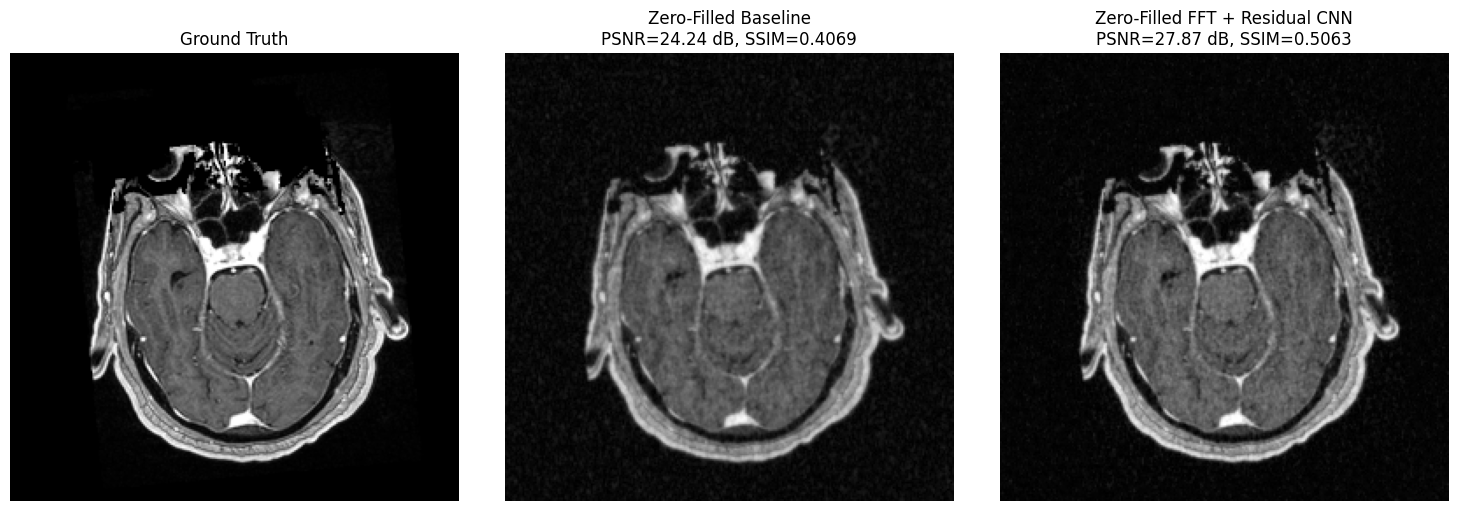

PSNR before CNN: 24.24 dB
PSNR after CNN: 27.87 dB
Improvement: +3.63 dB


In [ ]:
# visual comparison on one representative test slice
rep_idx = representative_test_idx
rep_pos = test_indices.index(rep_idx)

x_zf = x_test[rep_pos:rep_pos+1].to(device)
y_true = y_test[rep_pos:rep_pos+1].to(device)

mask_t = mask.to(device)

k_full = torch.fft.fftshift(torch.fft.fft2(y_true, dim=(-2,-1)), dim=(-2,-1))
if mask_t.dim() == 2:
  y_obs = k_full * mask_t.unsqueeze(0).unsqueeze(0)
elif mask_t.dim() == 3:
  y_obs = k_full * mask_t.unsqueeze(0)
else:
  y_obs = k_full * mask_t

model_zf.eval()
with torch.no_grad():
  y_pred = model_zf(x_zf, y_obs, mask_t)

psnr_before = compute_psnr(x_zf, y_true).item()
psnr_after = compute_psnr(y_pred, y_true).item()

ssim_before = compute_ssim(x_zf, y_true).item()
ssim_after = compute_ssim(y_pred, y_true).item()

zf_np = x_zf.squeeze().detach().cpu().numpy()
pred_np = y_pred.squeeze().detach().cpu().numpy()
true_np = y_true.squeeze().detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(true_np, cmap="gray")
axes[0].set_title("Ground Truth")
axes[0].axis("off")

axes[1].imshow(zf_np, cmap="gray")
axes[1].set_title(f"Zero-Filled Baseline\nPSNR={psnr_before:.2f} dB, SSIM={ssim_before:.4f}")
axes[1].axis("off")

axes[2].imshow(pred_np, cmap="gray")
axes[2].set_title(f"Zero-Filled FFT + Residual CNN\nPSNR={psnr_after:.2f} dB, SSIM={ssim_after:.4f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"PSNR before CNN: {psnr_before:.2f} dB")
print(f"PSNR after CNN: {psnr_after:.2f} dB")
print(f"Improvement: {psnr_after - psnr_before:+.2f} dB")

SRCNN
# 3-layer Multi-Slice SRCNN following Dong(2015) for
    # Layer 1 — Patch extraction & representation: conv 9x9, 64 filters
    # Layer 2 — Non-linear mapping:               conv 5x5, 32 filters
    # Layer 3 — Reconstruction:                   conv 5x5,  1 filter
    # ReLU after layers 1 and 2; no activation after layer 3.
    # Input/output are single-channel (grayscale) images in [0, 1].

In [ ]:
"""# SRCNN Multi-Slice

Extends SRCNN to train across all slices instead of a single image.
Uses zero-filled FFT as input, same as the ZF residual CNN above.
Adds a data consistency step to match the other two pipelines.
"""

x_train_src = torch.stack([zf_recon_dict[i].unsqueeze(0) for i in train_indices], dim=0)
y_train_src  = target_images[train_indices].cpu().float()
x_val_src    = torch.stack([zf_recon_dict[i].unsqueeze(0) for i in val_indices], dim=0)
y_val_src    = target_images[val_indices].cpu().float()
x_test_src   = torch.stack([zf_recon_dict[i].unsqueeze(0) for i in test_indices], dim=0)
y_test_src   = target_images[test_indices].cpu().float()

srcnn_train_loader = DataLoader(PairDataset(x_train_src, y_train_src), batch_size=4, shuffle=True)
srcnn_val_loader   = DataLoader(PairDataset(x_val_src,   y_val_src),   batch_size=4, shuffle=False)
srcnn_test_loader  = DataLoader(PairDataset(x_test_src,  y_test_src),  batch_size=4, shuffle=False)

print("x_train_src:", x_train_src.shape)
print("x_val_src:  ", x_val_src.shape)
print("x_test_src: ", x_test_src.shape)

x_train_src: torch.Size([8, 1, 256, 256])
x_val_src:   torch.Size([3, 1, 256, 256])
x_test_src:  torch.Size([3, 1, 256, 256])


In [ ]:
class SRCNN_DC(nn.Module):
    """
    SRCNN following Dong (2015) with two additions:
    - residual connection (input is added back before data consistency)
    - data consistency step (measured k-space values are enforced)
    """
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Conv2d(1, 64, kernel_size=9, padding=4)
        self.layer2 = nn.Conv2d(64, 32, kernel_size=5, padding=2)
        self.layer3 = nn.Conv2d(32,  1, kernel_size=5, padding=2)
        self.relu   = nn.ReLU(inplace=True)

    def forward(self, x, y_obs, mask):
        out = self.relu(self.layer1(x))
        out = self.relu(self.layer2(out))
        out = self.layer3(out)
        x_refined = x + out
        x_dc = data_consistency(x_refined, y_obs, mask)
        return torch.clamp(x_dc, 0.0, 1.0)

model_srcnn = SRCNN_DC().to(device)
total_params = sum(p.numel() for p in model_srcnn.parameters())
print(model_srcnn)
print(f"Total trainable parameters: {total_params:,}")

SRCNN_DC(
  (layer1): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (layer2): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (layer3): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu): ReLU(inplace=True)
)
Total trainable parameters: 57,281


In [ ]:
# Note: moderate runtime, similar to the ZF residual CNN above

srcnn_optimizer = torch.optim.Adam([
    {'params': model_srcnn.layer1.parameters(), 'lr': 1e-4},
    {'params': model_srcnn.layer2.parameters(), 'lr': 1e-4},
    {'params': model_srcnn.layer3.parameters(), 'lr': 1e-5},
])

num_srcnn_epochs = 100
srcnn_train_loss_history = []
srcnn_val_loss_history   = []
mask_t = mask.to(device)

for epoch in range(num_srcnn_epochs):
    model_srcnn.train()
    running_loss, n_train = 0.0, 0
    for xb, yb in srcnn_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        k_full = torch.fft.fftshift(torch.fft.fft2(yb, dim=(-2,-1)), dim=(-2,-1))
        y_obs  = k_full * mask_t.unsqueeze(0).unsqueeze(0)
        srcnn_optimizer.zero_grad()
        pred = model_srcnn(xb, y_obs, mask_t)
        loss = F.mse_loss(pred, yb)
        loss.backward()
        srcnn_optimizer.step()
        running_loss += loss.item() * xb.size(0)
        n_train      += xb.size(0)

    model_srcnn.eval()
    val_loss, n_val = 0.0, 0
    with torch.no_grad():
        for xb, yb in srcnn_val_loader:
            xb, yb = xb.to(device), yb.to(device)
            k_full = torch.fft.fftshift(torch.fft.fft2(yb, dim=(-2,-1)), dim=(-2,-1))
            y_obs  = k_full * mask_t.unsqueeze(0).unsqueeze(0)
            pred   = model_srcnn(xb, y_obs, mask_t)
            val_loss += F.mse_loss(pred, yb).item() * xb.size(0)
            n_val    += xb.size(0)

    srcnn_train_loss_history.append(running_loss / n_train)
    srcnn_val_loss_history.append(val_loss / n_val)
    if epoch % 10 == 0 or epoch == num_srcnn_epochs - 1:
        print(f"Epoch {epoch:03d} | train={running_loss/n_train:.6f} | val={val_loss/n_val:.6f}")

Epoch 000 | train=0.001292 | val=0.001419
Epoch 010 | train=0.001035 | val=0.001157
Epoch 020 | train=0.000905 | val=0.001016
Epoch 030 | train=0.000812 | val=0.000915
Epoch 040 | train=0.000746 | val=0.000841
Epoch 050 | train=0.000694 | val=0.000785
Epoch 060 | train=0.000654 | val=0.000741
Epoch 070 | train=0.000622 | val=0.000706
Epoch 080 | train=0.000597 | val=0.000678
Epoch 090 | train=0.000576 | val=0.000656
Epoch 099 | train=0.000561 | val=0.000640


SRCNN Multi-Slice Test MSE:  0.000649
SRCNN Multi-Slice Test PSNR: 31.87 dB
SRCNN Multi-Slice Test SSIM: 0.6318


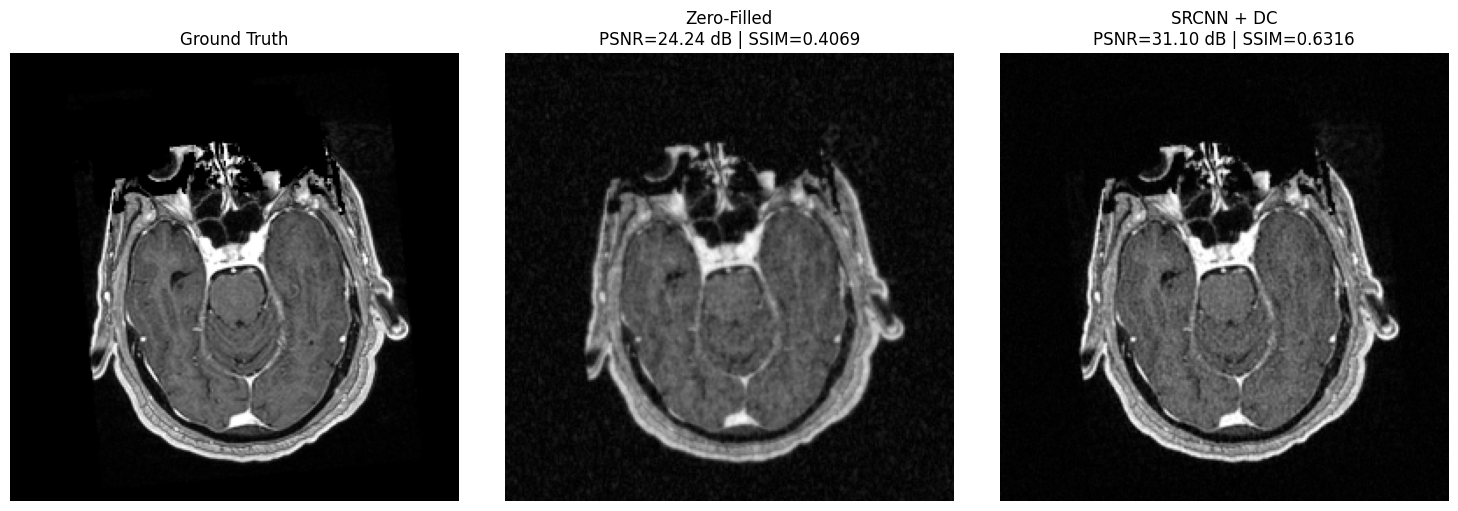

In [ ]:
model_srcnn.eval()
test_loss, test_psnr, test_ssim, n_test = 0.0,  0.0, 0.0, 0

with torch.no_grad():
    for xb, yb in srcnn_test_loader:
        xb, yb = xb.to(device), yb.to(device)
        k_full = torch.fft.fftshift(torch.fft.fft2(yb, dim=(-2,-1)), dim=(-2,-1))
        y_obs  = k_full * mask_t.unsqueeze(0).unsqueeze(0)
        pred   = model_srcnn(xb, y_obs, mask_t)
        bs = xb.size(0)
        test_loss += F.mse_loss(pred, yb).item() * bs
        test_psnr += compute_psnr(pred, yb).item() * bs
        test_ssim += compute_ssim(pred, yb).item() * bs
        n_test    += bs

print(f"SRCNN Multi-Slice Test MSE:  {test_loss/n_test:.6f}")
print(f"SRCNN Multi-Slice Test PSNR: {test_psnr/n_test:.2f} dB")
print(f"SRCNN Multi-Slice Test SSIM: {test_ssim/n_test:.4f}")

# image comparison on representative test slice
rep_pos    = test_indices.index(representative_test_idx)
x_src      = x_test_src[rep_pos:rep_pos+1].to(device)
y_true     = y_test_src[rep_pos:rep_pos+1].to(device)
k_full     = torch.fft.fftshift(torch.fft.fft2(y_true, dim=(-2,-1)), dim=(-2,-1))
y_obs      = k_full * mask_t.unsqueeze(0).unsqueeze(0)

with torch.no_grad():
    y_pred_src = model_srcnn(x_src, y_obs, mask_t)

psnr_zf  = compute_psnr(x_src,      y_true).item()
psnr_src = compute_psnr(y_pred_src,  y_true).item()
ssim_zf  = compute_ssim(x_src,      y_true).item()
ssim_src = compute_ssim(y_pred_src,  y_true).item()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(y_true.squeeze().cpu().numpy(),     cmap="gray"); axes[0].set_title("Ground Truth");          axes[0].axis("off")
axes[1].imshow(x_src.squeeze().cpu().numpy(),      cmap="gray"); axes[1].set_title(f"Zero-Filled\nPSNR={psnr_zf:.2f} dB | SSIM={ssim_zf:.4f}");  axes[1].axis("off")
axes[2].imshow(y_pred_src.squeeze().cpu().numpy(), cmap="gray"); axes[2].set_title(f"SRCNN + DC\nPSNR={psnr_src:.2f} dB | SSIM={ssim_src:.4f}"); axes[2].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# U-Net for MRI Reconstruction


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, ch=32):
        super().__init__()
        # encoder
        self.enc1 = ConvBlock(1, ch)
        self.enc2 = ConvBlock(ch, ch*2)
        self.enc3 = ConvBlock(ch*2, ch*4)
        self.pool = nn.MaxPool2d(2)
        # bottleneck
        self.bottleneck = ConvBlock(ch*4, ch*8)
        # decoder
        self.up3   = nn.ConvTranspose2d(ch*8, ch*4, 2, stride=2)
        self.dec3  = ConvBlock(ch*8, ch*4)
        self.up2   = nn.ConvTranspose2d(ch*4, ch*2, 2, stride=2)
        self.dec2  = ConvBlock(ch*4, ch*2)
        self.up1   = nn.ConvTranspose2d(ch*2, ch, 2, stride=2)
        self.dec1  = ConvBlock(ch*2, ch)
        self.head  = nn.Conv2d(ch, 1, 1)

    def forward(self, x, y_obs, mask):
        # encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        # bottleneck
        b  = self.bottleneck(self.pool(e3))
        # decoder with skip connections
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        out = self.head(d1)
        # residual + data consistency
        x_refined = x + out
        x_dc = data_consistency(x_refined, y_obs, mask)
        return torch.clamp(x_dc, 0.0, 1.0)

model_unet = UNet(ch=32).to(device)
total_params = sum(p.numel() for p in model_unet.parameters())
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 1,927,841


In [ ]:
# reuses zero-filled reconstructions already computed above
x_train_unet = torch.stack([zf_recon_dict[i].unsqueeze(0) for i in train_indices], dim=0)
y_train_unet = target_images[train_indices].cpu().float()
x_val_unet   = torch.stack([zf_recon_dict[i].unsqueeze(0) for i in val_indices], dim=0)
y_val_unet   = target_images[val_indices].cpu().float()
x_test_unet  = torch.stack([zf_recon_dict[i].unsqueeze(0) for i in test_indices], dim=0)
y_test_unet  = target_images[test_indices].cpu().float()

unet_train_loader = DataLoader(PairDataset(x_train_unet, y_train_unet), batch_size=4, shuffle=True)
unet_val_loader   = DataLoader(PairDataset(x_val_unet,   y_val_unet),   batch_size=4, shuffle=False)
unet_test_loader  = DataLoader(PairDataset(x_test_unet,  y_test_unet),  batch_size=4, shuffle=False)

In [ ]:
# Note: moderate runtime on T4, similar to the other CNN training cells

unet_optimizer = torch.optim.Adam(model_unet.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(unet_optimizer, step_size=20, gamma=0.5)

num_unet_epochs = 50
unet_train_loss_history = []
unet_val_loss_history   = []
mask_t = mask.to(device)

for epoch in range(num_unet_epochs):
    model_unet.train()
    running_loss, n_train = 0.0, 0
    for xb, yb in unet_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        k_full = torch.fft.fftshift(torch.fft.fft2(yb, dim=(-2,-1)), dim=(-2,-1))
        y_obs  = k_full * mask_t.unsqueeze(0).unsqueeze(0)
        unet_optimizer.zero_grad()
        pred = model_unet(xb, y_obs, mask_t)
        loss = F.mse_loss(pred, yb)
        loss.backward()
        unet_optimizer.step()
        running_loss += loss.item() * xb.size(0)
        n_train      += xb.size(0)

    model_unet.eval()
    val_loss, n_val = 0.0, 0
    with torch.no_grad():
        for xb, yb in unet_val_loader:
            xb, yb = xb.to(device), yb.to(device)
            k_full = torch.fft.fftshift(torch.fft.fft2(yb, dim=(-2,-1)), dim=(-2,-1))
            y_obs  = k_full * mask_t.unsqueeze(0).unsqueeze(0)
            pred   = model_unet(xb, y_obs, mask_t)
            val_loss += F.mse_loss(pred, yb).item() * xb.size(0)
            n_val    += xb.size(0)

    scheduler.step()
    unet_train_loss_history.append(running_loss / n_train)
    unet_val_loss_history.append(val_loss / n_val)
    if epoch % 10 == 0 or epoch == num_unet_epochs - 1:
        print(f"Epoch {epoch:03d} | train={running_loss/n_train:.6f} | val={val_loss/n_val:.6f}")

Epoch 000 | train=0.021436 | val=0.001453
Epoch 010 | train=0.000928 | val=0.001316
Epoch 020 | train=0.000730 | val=0.001124
Epoch 030 | train=0.000660 | val=0.000854
Epoch 040 | train=0.000610 | val=0.000699
Epoch 049 | train=0.000591 | val=0.000665


U-Net Test MSE:  0.000683
U-Net Test PSNR: 31.65 dB
U-Net Test SSIM: 0.6163


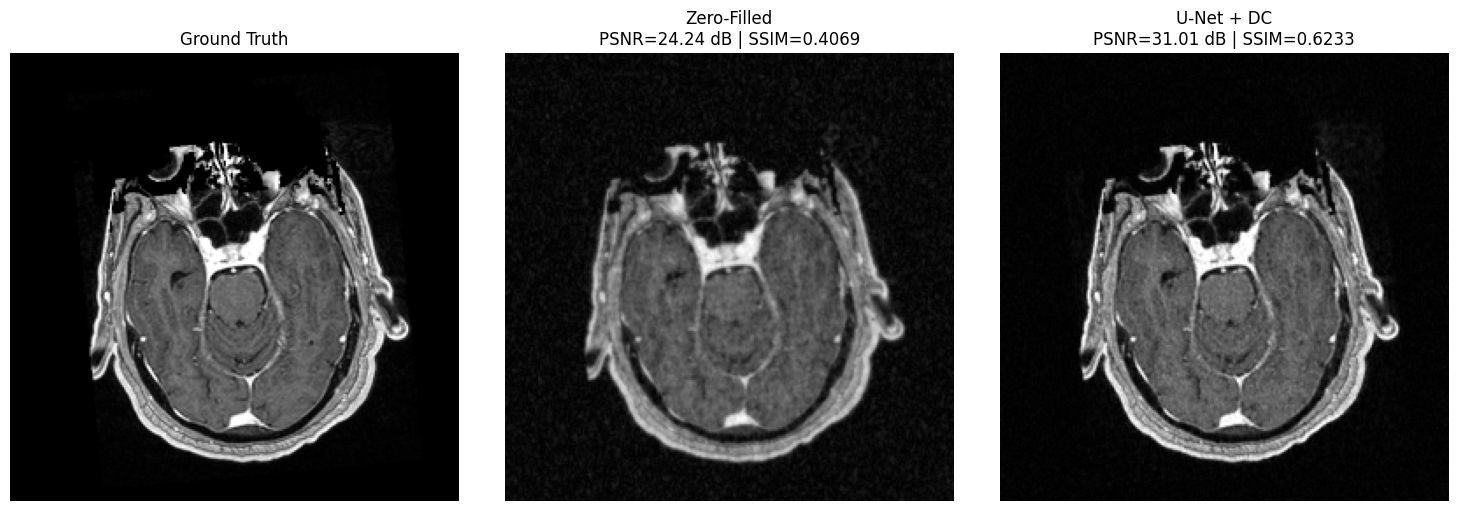

PSNR improvement over zero-filled: +6.77 dB
SSIM improvement over zero-filled: +0.2164


In [ ]:
model_unet.eval()
test_loss, test_psnr, test_ssim, n_test = 0.0, 0.0, 0.0, 0

with torch.no_grad():
    for xb, yb in unet_test_loader:
        xb, yb = xb.to(device), yb.to(device)
        k_full = torch.fft.fftshift(torch.fft.fft2(yb, dim=(-2,-1)), dim=(-2,-1))
        y_obs  = k_full * mask_t.unsqueeze(0).unsqueeze(0)
        pred   = model_unet(xb, y_obs, mask_t)
        bs = xb.size(0)
        test_loss += F.mse_loss(pred, yb).item() * bs
        test_psnr += compute_psnr(pred, yb).item() * bs
        test_ssim += compute_ssim(pred, yb).item() * bs
        n_test    += bs

print(f"U-Net Test MSE:  {test_loss/n_test:.6f}")
print(f"U-Net Test PSNR: {test_psnr/n_test:.2f} dB")
print(f"U-Net Test SSIM: {test_ssim/n_test:.4f}")

# image comparison on representative test slice
rep_pos    = test_indices.index(representative_test_idx)
x_un       = x_test_unet[rep_pos:rep_pos+1].to(device)
y_true     = y_test_unet[rep_pos:rep_pos+1].to(device)
k_full     = torch.fft.fftshift(torch.fft.fft2(y_true, dim=(-2,-1)), dim=(-2,-1))
y_obs      = k_full * mask_t.unsqueeze(0).unsqueeze(0)

with torch.no_grad():
    y_pred_unet = model_unet(x_un, y_obs, mask_t)

psnr_zf   = compute_psnr(x_un,        y_true).item()
psnr_unet = compute_psnr(y_pred_unet,  y_true).item()
ssim_zf   = compute_ssim(x_un,        y_true).item()
ssim_unet = compute_ssim(y_pred_unet,  y_true).item()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(y_true.squeeze().cpu().numpy(),      cmap="gray"); axes[0].set_title("Ground Truth");         axes[0].axis("off")
axes[1].imshow(x_un.squeeze().cpu().numpy(),        cmap="gray"); axes[1].set_title(f"Zero-Filled\nPSNR={psnr_zf:.2f} dB | SSIM={ssim_zf:.4f}");  axes[1].axis("off")
axes[2].imshow(y_pred_unet.squeeze().cpu().numpy(), cmap="gray"); axes[2].set_title(f"U-Net + DC\nPSNR={psnr_unet:.2f} dB | SSIM={ssim_unet:.4f}"); axes[2].axis("off")
plt.tight_layout()
plt.show()

print(f"PSNR improvement over zero-filled: {psnr_unet - psnr_zf:+.2f} dB")
print(f"SSIM improvement over zero-filled: {ssim_unet - ssim_zf:+.4f}")

# Diffusion on Kernel Reconstruction

In [ ]:
x_train = torch.stack([kernel_recon_dict[i].unsqueeze(0) for i in train_indices], dim=0).float()
y_train = target_images[train_indices].cpu().float()

x_val = torch.stack([kernel_recon_dict[i].unsqueeze(0) for i in val_indices], dim=0).float()
y_val = target_images[val_indices].cpu().float()

x_test = torch.stack([kernel_recon_dict[i].unsqueeze(0) for i in test_indices], dim=0).float()
y_test = target_images[test_indices].cpu().float()

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_val:", x_val.shape, "y_val:", y_val.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)

x_train: torch.Size([8, 1, 256, 256]) y_train: torch.Size([8, 1, 256, 256])
x_val: torch.Size([3, 1, 256, 256]) y_val: torch.Size([3, 1, 256, 256])
x_test: torch.Size([3, 1, 256, 256]) y_test: torch.Size([3, 1, 256, 256])


In [ ]:
class PairDataset(Dataset):
  def __init__(self, x, y):
    self.x = x
    self.y = y

  def __len__(self):
    return len(self.x)

  def __getitem__(self, idx):
    return self.x[idx], self.y[idx]

diff_train_loader = DataLoader(PairDataset(x_train, y_train), batch_size=4, shuffle=True)
diff_val_loader = DataLoader(PairDataset(x_val, y_val), batch_size=4, shuffle=False)
diff_test_loader = DataLoader(PairDataset(x_test, y_test), batch_size=4, shuffle=False)

In [ ]:
def data_consistency_projection(x, y_obs, mask):
  """
  x: [B, 1, H, W] is the real image estimate
  y_obs: [B, 1, H, W] is the complex undersampled k-space
  mask: [H, W] or [1, H, W] or [B, 1, H, W]
  """
  k = torch.fft.fftshift(torch.fft.fft2(x, dim=(-2, -1)), dim=(-2, -1))

  if mask.dim() == 2:
    mask_exp = mask.unsqueeze(0).unsqueeze(0)
  elif mask.dim() == 3:
    mask_exp = mask.unsqueeze(0)
  else:
    mask_exp = mask

  mask_exp = mask_exp.to(x.device)

  # this enforces observed k-space, only modify unobserved region
  k_proj = mask_exp * y_obs + (1.0 - mask_exp) * k
  x_proj = torch.fft.ifft2(torch.fft.ifftshift(k_proj, dim=(-2, -1)), dim=(-2,-1)).real

  return torch.clamp(x_proj, 0.0, 1.0)

In [ ]:
T = 100

betas = torch.linspace(1e-4, 2e-2, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def extract(a, t, x_shape):
  """
  a: [T]
  t: [B]
  returns shape [B, 1, 1, 1] for broadcasting
  """
  out = a.gather(0, t)
  return out.view(-1, 1, 1, 1)

def q_sample(x0, t, noise=None):
  """
  Forward diffusion:
  x_t=sqrt(alpha_bar_t) x0 + sqrt(1-alpha_bar_t) eps
  """
  if noise is None:
    noise = torch.randn_like(x0)

  sqrt_ab = torch.sqrt(extract(alpha_bars, t, x0.shape))
  sqrt_1mab = torch.sqrt(1.0 - extract(alpha_bars, t, x0.shape))
  return sqrt_ab * x0 + sqrt_1mab * noise, noise

In [ ]:
# timestep
class SinusoidalTimeEmbedding(nn.Module):
  def __init__(self, dim):
    super().__init__()
    self.dim = dim

  def forward(self, t):
    half_dim = self.dim // 2
    emb_scale = math.log(10000) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb_scale)
    emb = t.float().unsqueeze(1) * emb.unsqueeze(0)
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    return emb

In [ ]:
# kernel denoiser
class DiffusionKernelDenoiser(nn.Module):
  def __init__(self, time_dim=64, ch=64):
    super().__init__()

    self.time_mlp = nn.Sequential(
        SinusoidalTimeEmbedding(time_dim),
        nn.Linear(time_dim, time_dim),
        nn.ReLU(inplace=True),
        nn.Linear(time_dim, time_dim),
    )

    self.conv1 = nn.Conv2d(2, ch, 3, padding=1) # [x_t, x_kernel]
    self.conv2 = nn.Conv2d(ch, ch, 3, padding=1)
    self.conv3 = nn.Conv2d(ch, ch, 3, padding=1)
    self.conv4 = nn.Conv2d(ch, 1, 3, padding=1)

    self.time_proj1 = nn.Linear(time_dim, ch)
    self.time_proj2 = nn.Linear(time_dim, ch)
    self.time_proj3 = nn.Linear(time_dim, ch)

    self.act = nn.ReLU(inplace=True)

  def forward(self, x_t, x_kernel, t):
    temb = self.time_mlp(t) # [B, time_dim]

    h = torch.cat([x_t, x_kernel], dim=1)

    h = self.conv1(h)
    h = h + self.time_proj1(temb).unsqueeze(-1).unsqueeze(-1)
    h = self.act(h)

    h = self.conv2(h)
    h = h + self.time_proj2(temb).unsqueeze(-1).unsqueeze(-1)
    h = self.act(h)

    h = self.conv3(h)
    h = h + self.time_proj3(temb).unsqueeze(-1).unsqueeze(-1)
    h = self.act(h)

    eps_pred = self.conv4(h)
    return eps_pred

In [ ]:
model_diff = DiffusionKernelDenoiser(time_dim=64, ch=64).to(device)
print(model_diff)

DiffusionKernelDenoiser(
  (time_mlp): Sequential(
    (0): SinusoidalTimeEmbedding()
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=64, out_features=64, bias=True)
  )
  (conv1): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj1): Linear(in_features=64, out_features=64, bias=True)
  (time_proj2): Linear(in_features=64, out_features=64, bias=True)
  (time_proj3): Linear(in_features=64, out_features=64, bias=True)
  (act): ReLU(inplace=True)
)


In [ ]:
# training loss
optimizer = torch.optim.Adam(model_diff.parameters(), lr=1e-3)

num_epochs = 50
mask_t = mask.to(device)

train_loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
  model_diff.train()
  running_train_loss = 0.0
  n_train = 0

  for x_kernel, y_true in diff_train_loader:
    x_kernel = x_kernel.to(device)
    y_true = y_true.to(device)

    bsz = y_true.size(0)
    t = torch.randint(0, T, (bsz,), device=device)

    x_t, noise = q_sample(y_true, t)
    eps_pred = model_diff(x_t, x_kernel, t)

    loss = F.mse_loss(eps_pred, noise)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_train_loss += loss.item() * bsz
    n_train += bsz

  train_loss = running_train_loss / n_train
  train_loss_history.append(train_loss)

  model_diff.eval()
  running_val_loss = 0.0
  n_val = 0

  with torch.no_grad():
    for x_kernel, y_true in diff_val_loader:
      x_kernel = x_kernel.to(device)
      y_true = y_true.to(device)

      bsz = y_true.size(0)
      t = torch.randint(0, T, (bsz,), device=device)

      x_t, noise = q_sample(y_true, t)
      eps_pred = model_diff(x_t, x_kernel, t)

      loss = F.mse_loss(eps_pred, noise)

      running_val_loss += loss.item() * bsz
      n_val += bsz

  val_loss = running_val_loss / n_val
  val_loss_history.append(val_loss)

  print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch 01/50 | Train Loss: 0.988246 | Val Loss: 0.933129
Epoch 02/50 | Train Loss: 0.900919 | Val Loss: 0.836744
Epoch 03/50 | Train Loss: 0.769991 | Val Loss: 0.677426
Epoch 04/50 | Train Loss: 0.560991 | Val Loss: 0.305283
Epoch 05/50 | Train Loss: 0.514670 | Val Loss: 0.087982
Epoch 06/50 | Train Loss: 0.216718 | Val Loss: 0.253378
Epoch 07/50 | Train Loss: 0.494829 | Val Loss: 0.189848
Epoch 08/50 | Train Loss: 0.457494 | Val Loss: 0.444037
Epoch 09/50 | Train Loss: 0.326071 | Val Loss: 0.235961
Epoch 10/50 | Train Loss: 0.238955 | Val Loss: 0.282682
Epoch 11/50 | Train Loss: 0.258211 | Val Loss: 0.341478
Epoch 12/50 | Train Loss: 0.149834 | Val Loss: 0.430950
Epoch 13/50 | Train Loss: 0.117356 | Val Loss: 0.088420
Epoch 14/50 | Train Loss: 0.231918 | Val Loss: 0.053552
Epoch 15/50 | Train Loss: 0.051488 | Val Loss: 0.052293
Epoch 16/50 | Train Loss: 0.209592 | Val Loss: 0.079777
Epoch 17/50 | Train Loss: 0.275056 | Val Loss: 0.370978
Epoch 18/50 | Train Loss: 0.075506 | Val Loss: 0

In [ ]:
# diffusion keeping k-space samples
@torch.no_grad()
def diffusion_sample_with_dc(model, x_kernel, y_obs, mask, num_steps=T, start_from_kernel=True):
  model.eval()

  bsz = x_kernel.size(0)

  if start_from_kernel:
    x = x_kernel + 0.05 * torch.randn_like(x_kernel)
  else:
    x = torch.randn_like(x_kernel)

  for step in reversed(range(num_steps)):
    t = torch.full((bsz,), step, device=x_kernel.device, dtype=torch.long)

    beta_t = extract(betas, t, x.shape)
    alpha_t = extract(alphas, t, x.shape)
    alpha_bar_t = extract(alpha_bars, t, x.shape)

    eps_pred = model(x, x_kernel, t)

    x = (1.0 / torch.sqrt(alpha_t)) * (
        x - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)) * eps_pred
    )

    if step > 0:
      z = torch.randn_like(x)
      x = x + torch.sqrt(beta_t) * z

    # enforces data consistency
    x = data_consistency_projection(x, y_obs, mask)

  return torch.clamp(x, 0.0, 1.0)

In [ ]:
# test eval
model_diff.eval()

test_mse = 0.0
test_psnr = 0.0
test_ssim = 0.0
n_test = 0

mask_t = mask.to(device)

with torch.no_grad():
  for x_kernel, y_true in diff_test_loader:
    x_kernel = x_kernel.to(device)
    y_true = y_true.to(device)

    k_full = torch.fft.fftshift(torch.fft.fft2(y_true, dim=(-2, -1)), dim=(-2, -1))
    if mask_t.dim() == 2:
      y_obs = k_full * mask_t.unsqueeze(0).unsqueeze(0)
    elif mask_t.dim() == 3:
      y_obs = k_full * mask_t.unsqeeuze(0)
    else:
      y_obs = k_full * mask_t

    pred = diffusion_sample_with_dc(model_diff, x_kernel, y_obs, mask_t, num_steps=T)

    bs = x_kernel.size(0)
    test_mse += F.mse_loss(pred, y_true).item() * bs
    test_psnr += compute_psnr(pred, y_true).item() * bs

    if "compute_ssim" in globals():
      test_ssim += compute_ssim(pred, y_true).item() * bs

    n_test += bs

print(f"Kernel + Diffusion + DC Test MSE: {test_mse/n_test:.6f}")
print(f"Kernel + Diffusion + DC Test PSNR:{test_psnr/n_test:.2f} dB")
if "compute_ssim" in globals():
  print(f"Kernel + Diffusion + DC Test SSIM: {test_ssim/n_test:.4f}")

Kernel + Diffusion + DC Test MSE: 0.000713
Kernel + Diffusion + DC Test PSNR:31.47 dB
Kernel + Diffusion + DC Test SSIM: 0.7777


PSNR before diffusion: 18.08 dB
PSNR after diffusion: 30.59 dB
SSIM before diffusion: 0.4150
SSIM after diffusion: 0.7627


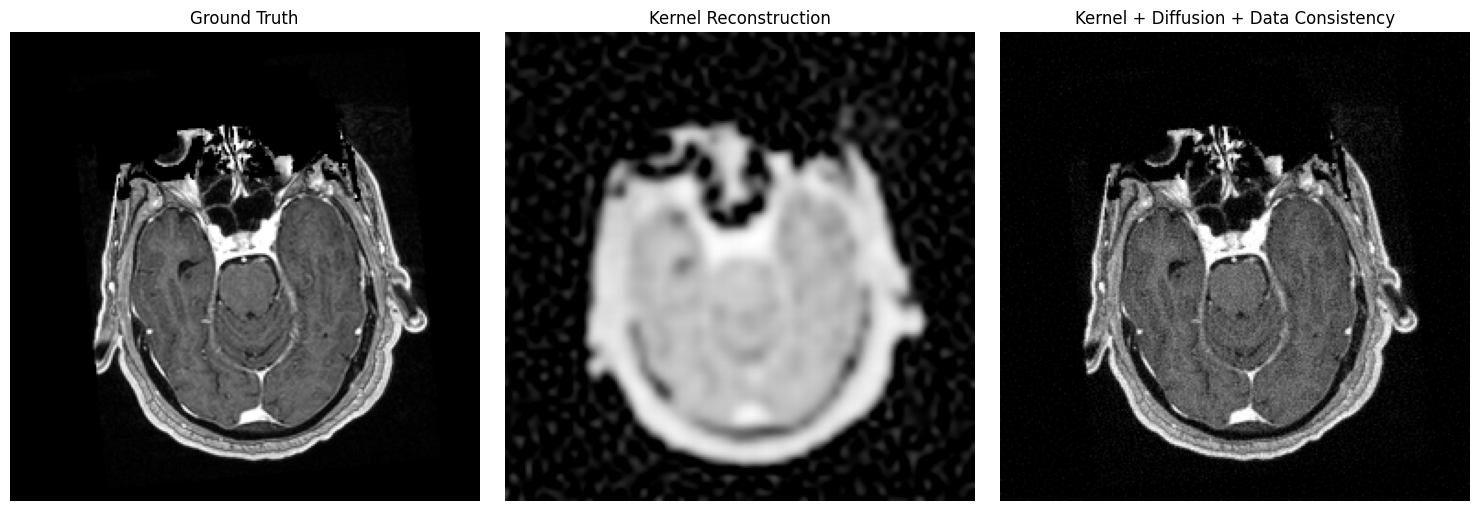

In [ ]:
# visualize a representative slice
rep_idx = representative_test_idx
rep_pos = test_indices.index(rep_idx)

x_kernel_rep = x_test[rep_pos:rep_pos+1].to(device)
y_true_rep = y_test[rep_pos:rep_pos+1].to(device)

mask_t = mask.to(device)

k_full = torch.fft.fftshift(torch.fft.fft2(y_true_rep, dim=(-2,-1)), dim=(-2,-1))
if mask_t.dim() == 2:
  y_obs = k_full * mask_t.unsqueeze(0).unsqueeze(0)
elif mask_t.dim() == 3:
  y_obs = k_full * mask_t.unsqueeze(0)
else:
  y_obs = k_full * mask_t

with torch.no_grad():
  y_pred_rep = diffusion_sample_with_dc(model_diff, x_kernel_rep, y_obs, mask_t, num_steps=T)

psnr_before = compute_psnr(x_kernel_rep, y_true_rep).item()
psnr_after = compute_psnr(y_pred_rep, y_true_rep).item()

print(f"PSNR before diffusion: {psnr_before:.2f} dB")
print(f"PSNR after diffusion: {psnr_after:.2f} dB")

if "compute_ssim" in globals():
  ssim_before = compute_ssim(x_kernel_rep, y_true_rep).item()
  ssim_after = compute_ssim(y_pred_rep, y_true_rep).item()
  print(f"SSIM before diffusion: {ssim_before:.4f}")
  print(f"SSIM after diffusion: {ssim_after:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(y_true_rep[0,0].detach().cpu(), cmap="gray")
axes[0].set_title("Ground Truth")
axes[0].axis("off")

axes[1].imshow(x_kernel_rep[0,0].detach().cpu(), cmap="gray")
axes[1].set_title("Kernel Reconstruction")
axes[1].axis("off")

axes[2].imshow(y_pred_rep[0,0].detach().cpu(), cmap="gray")
axes[2].set_title("Kernel + Diffusion + Data Consistency")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Diffusion Model with Zero-filled FFT

In [ ]:
# zero-filled reconstruction
def zero_filled_reconstruction(img, mask):
  """
  img: [H, W] or [1, H, W]
  mask: [H, W]
  returns: [H, W] real zero-filled reconstruction
  """
  if img.dim() == 3:
    img2d = img[0]
  else:
    img2d = img

  k_full = torch.fft.fftshift(torch.fft.fft2(img2d), dim=(-2, -1))
  k_under = k_full * mask.to(img.device)

  x_zf = torch.fft.ifft2(torch.fft.ifftshift(k_under, dim=(-2,-1))).real
  x_zf = torch.clamp(x_zf, 0.0, 1.0)
  return x_zf

In [ ]:
zf_recon_dict = {}

for i in range(target_images.shape[0]):
  img = target_images[i].cpu()
  zf_recon_dict[i] = zero_filled_reconstruction(img, mask.cpu())

print(f"Built {len(zf_recon_dict)} zero-filled reconstructions")

Built 96 zero-filled reconstructions


In [ ]:
# train / val / test
x_train_zf = torch.stack([zf_recon_dict[i].unsqueeze(0) for i in train_indices], dim=0).float()
y_train = target_images[train_indices].cpu().float()

x_val_zf = torch.stack([zf_recon_dict[i].unsqueeze(0) for i in val_indices], dim=0).float()
y_val = target_images[val_indices].cpu().float()

x_test_zf = torch.stack([zf_recon_dict[i].unsqueeze(0) for i in test_indices], dim=0).float()
y_test = target_images[test_indices].cpu().float()

print("x_train_zf:", x_train_zf.shape, "y_train:", y_train.shape)
print("x_val_zf:", x_val_zf.shape, "y_val:", y_val.shape)
print("x_test_zf:", x_test_zf.shape, "y_test:", y_test.shape)

x_train_zf: torch.Size([8, 1, 256, 256]) y_train: torch.Size([8, 1, 256, 256])
x_val_zf: torch.Size([3, 1, 256, 256]) y_val: torch.Size([3, 1, 256, 256])
x_test_zf: torch.Size([3, 1, 256, 256]) y_test: torch.Size([3, 1, 256, 256])


In [ ]:
class PairDataset(Dataset):
  def __init__(self, x, y):
    self.x = x
    self.y = y

  def __len__(self):
    return len(self.x)

  def __getitem__(self, idx):
    return self.x[idx], self.y[idx]

diff_train_loader_zf = DataLoader(PairDataset(x_train_zf, y_train), batch_size=4, shuffle=True)
diff_val_loader_zf = DataLoader(PairDataset(x_val_zf, y_val), batch_size=4, shuffle=False)
diff_test_loader_zf = DataLoader(PairDataset(x_test_zf, y_test), batch_size=4, shuffle=False)

In [ ]:
# data consistency (same as kernel diffusion)
def data_consistency_projection(x, y_obs, mask):
  """
  x: [B, 1, H, W] is the real image estimate
  y_obs: [B, 1, H, W] is the complex undersampled k-space
  mask: [H, W] or [1, H, W] or [B, 1, H, W]
  """
  k = torch.fft.fftshift(torch.fft.fft2(x, dim=(-2, -1)), dim=(-2, -1))

  if mask.dim() == 2:
    mask_exp = mask.unsqueeze(0).unsqueeze(0)
  elif mask.dim() == 3:
    mask_exp = mask.unsqueeze(0)
  else:
    mask_exp = mask

  mask_exp = mask_exp.to(x.device)

  # this enforces observed k-space, only modify unobserved region
  k_proj = mask_exp * y_obs + (1.0 - mask_exp) * k
  x_proj = torch.fft.ifft2(torch.fft.ifftshift(k_proj, dim=(-2, -1)), dim=(-2,-1)).real

  return torch.clamp(x_proj, 0.0, 1.0)

In [ ]:
# diffusion set up (same as kernel)
T = 100

betas = torch.linspace(1e-4, 2e-2, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def extract(a, t, x_shape):
  """
  a: [T]
  t: [B]
  returns shape [B, 1, 1, 1] for broadcasting
  """
  out = a.gather(0, t)
  return out.view(-1, 1, 1, 1)

def q_sample(x0, t, noise=None):
  """
  Forward diffusion:
  x_t=sqrt(alpha_bar_t) x0 + sqrt(1-alpha_bar_t) eps
  """
  if noise is None:
    noise = torch.randn_like(x0)

  sqrt_ab = torch.sqrt(extract(alpha_bars, t, x0.shape))
  sqrt_1mab = torch.sqrt(1.0 - extract(alpha_bars, t, x0.shape))
  return sqrt_ab * x0 + sqrt_1mab * noise, noise

In [ ]:
# timestep again same as kernel reconstruction
class SinusoidalTimeEmbedding(nn.Module):
  def __init__(self, dim):
    super().__init__()
    self.dim = dim

  def forward(self, t):
    half_dim = self.dim // 2
    emb_scale = math.log(10000) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb_scale)
    emb = t.float().unsqueeze(1) * emb.unsqueeze(0)
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    return emb

In [ ]:
# zero-filled denoiser (same construction as kernel but with x_zf instead of x_kernel)
class DiffusionZFDenoiser(nn.Module):
  def __init__(self, time_dim=64, ch=64):
    super().__init__()

    self.time_mlp = nn.Sequential(
        SinusoidalTimeEmbedding(time_dim),
        nn.Linear(time_dim, time_dim),
        nn.ReLU(inplace=True),
        nn.Linear(time_dim, time_dim),
    )

    self.conv1 = nn.Conv2d(2, ch, 3, padding=1) # [x_t, x_zf]
    self.conv2 = nn.Conv2d(ch, ch, 3, padding=1)
    self.conv3 = nn.Conv2d(ch, ch, 3, padding=1)
    self.conv4 = nn.Conv2d(ch, 1, 3, padding=1)

    self.time_proj1 = nn.Linear(time_dim, ch)
    self.time_proj2 = nn.Linear(time_dim, ch)
    self.time_proj3 = nn.Linear(time_dim, ch)

    self.act = nn.ReLU(inplace=True)

  def forward(self, x_t, x_zf, t):
    temb = self.time_mlp(t)

    h = torch.cat([x_t, x_zf], dim=1)

    h = self.conv1(h)
    h = h + self.time_proj1(temb).unsqueeze(-1).unsqueeze(-1)
    h = self.act(h)

    h = self.conv2(h)
    h = h + self.time_proj2(temb).unsqueeze(-1).unsqueeze(-1)
    h = self.act(h)

    h = self.conv3(h)
    h = h + self.time_proj3(temb).unsqueeze(-1).unsqueeze(-1)
    h = self.act(h)

    eps_pred = self.conv4(h)
    return eps_pred

In [ ]:
model_diff_zf = DiffusionZFDenoiser(time_dim=64, ch=64).to(device)
print(model_diff_zf)

DiffusionZFDenoiser(
  (time_mlp): Sequential(
    (0): SinusoidalTimeEmbedding()
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=64, out_features=64, bias=True)
  )
  (conv1): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj1): Linear(in_features=64, out_features=64, bias=True)
  (time_proj2): Linear(in_features=64, out_features=64, bias=True)
  (time_proj3): Linear(in_features=64, out_features=64, bias=True)
  (act): ReLU(inplace=True)
)


In [ ]:
# train zero-filled diffusion
optimizer_zf = torch.optim.Adam(model_diff_zf.parameters(), lr=1e-3)

num_epochs = 50
train_loss_history_zf = []
val_loss_history_zf = []

for epoch in range(num_epochs):
  model_diff_zf.train()
  running_train_loss = 0.0
  n_train = 0

  for x_zf, y_true in diff_train_loader_zf:
    x_zf = x_zf.to(device)
    y_true = y_true.to(device)

    bsz = y_true.size(0)
    t = torch.randint(0, T, (bsz,), device=device)

    x_t, noise = q_sample(y_true, t)
    eps_pred = model_diff_zf(x_t, x_zf, t)

    loss = F.mse_loss(eps_pred, noise)

    optimizer_zf.zero_grad()
    loss.backward()
    optimizer_zf.step()

    running_train_loss += loss.item() * bsz
    n_train += bsz

  train_loss = running_train_loss / n_train
  train_loss_history_zf.append(train_loss)

  model_diff_zf.eval()
  running_val_loss = 0.0
  n_val = 0

  with torch.no_grad():
    for x_zf, y_true in diff_val_loader_zf:
      x_zf = x_zf.to(device)
      y_true = y_true.to(device)

      bsz = y_true.size(0)
      t = torch.randint(0, T, (bsz,), device=device)

      x_t, noise = q_sample(y_true, t)
      eps_pred = model_diff_zf(x_t, x_zf, t)

      loss = F.mse_loss(eps_pred, noise)

      running_val_loss += loss.item() * bsz
      n_val += bsz

  val_loss = running_val_loss / n_val
  val_loss_history_zf.append(val_loss)
  print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch 01/50 | Train Loss: 0.974596 | Val Loss: 0.920396
Epoch 02/50 | Train Loss: 0.832654 | Val Loss: 0.742980
Epoch 03/50 | Train Loss: 0.707782 | Val Loss: 0.700446
Epoch 04/50 | Train Loss: 0.486337 | Val Loss: 0.450251
Epoch 05/50 | Train Loss: 0.281000 | Val Loss: 0.487090
Epoch 06/50 | Train Loss: 0.259735 | Val Loss: 0.245785
Epoch 07/50 | Train Loss: 0.295686 | Val Loss: 0.323712
Epoch 08/50 | Train Loss: 0.289339 | Val Loss: 0.120476
Epoch 09/50 | Train Loss: 0.122588 | Val Loss: 0.060860
Epoch 10/50 | Train Loss: 0.177112 | Val Loss: 0.123601
Epoch 11/50 | Train Loss: 0.127924 | Val Loss: 0.077990
Epoch 12/50 | Train Loss: 0.188964 | Val Loss: 0.373145
Epoch 13/50 | Train Loss: 0.211311 | Val Loss: 0.444188
Epoch 14/50 | Train Loss: 0.078330 | Val Loss: 0.156091
Epoch 15/50 | Train Loss: 0.079931 | Val Loss: 0.045366
Epoch 16/50 | Train Loss: 0.155195 | Val Loss: 0.115353
Epoch 17/50 | Train Loss: 0.206453 | Val Loss: 0.048085
Epoch 18/50 | Train Loss: 0.196521 | Val Loss: 0

In [ ]:
# diffusion with data consistency
@torch.no_grad()
def diffusion_sample_with_dc_zf(model, x_df, y_obs, mask, num_steps=T, start_from_zf=True):
  model.eval()

  bsz = x_zf.size(0)

  if start_from_zf:
    x = x_zf + 0.05 * torch.randn_like(x_zf)
  else:
    x = torch.randn_like(x_zf)

  for step in reversed(range(num_steps)):
    t = torch.full((bsz,), step, device=x_zf.device, dtype=torch.long)

    beta_t = extract(betas, t, x.shape)
    alpha_t = extract(alphas, t, x.shape)
    alpha_bar_t = extract(alpha_bars, t, x.shape)

    eps_pred = model(x, x_zf, t)

    x = (1.0 / torch.sqrt(alpha_t)) * (
        x - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)) * eps_pred
    )

    if step > 0:
      z = torch.randn_like(x)
      x = x + torch.sqrt(beta_t) * z

    # enforces k-space consistency
    x = data_consistency_projection(x, y_obs, mask)

  return torch.clamp(x, 0.0, 1.0)

In [ ]:
# test eval
model_diff_zf.eval()

test_mse_zf = 0.0
test_psnr_zf = 0.0
test_ssim_zf = 0.0
n_test = 0

mask_t = mask.to(device)
with torch.no_grad():
  for x_zf, y_true in diff_test_loader_zf:
    x_zf = x_zf.to(device)
    y_true = y_true.to(device)

    k_full = torch.fft.fftshift(torch.fft.fft2(y_true, dim=(-2, -1)), dim=(-2, -1))

    if mask_t.dim() == 2:
      y_obs = k_full * mask_t.unsqueeze(0).unsqueeze(0)
    elif mask_t.dim() == 3:
      y_obs = k_full * mask_t.unsqueeze(0)
    else:
      y_obs = k_full * mask_t

    pred = diffusion_sample_with_dc_zf(model_diff_zf, x_zf, y_obs, mask_t, num_steps=T)

    bs = x_zf.size(0)
    test_mse_zf += F.mse_loss(pred, y_true).item() * bs
    test_psnr_zf += compute_psnr(pred, y_true).item() * bs
    if "compute_ssim" in globals():
      test_ssim_zf += compute_ssim(pred, y_true).item() * bs

    n_test += bs

print(f"ZF + Diffusion + DC Test MSE: {test_mse_zf/n_test:.6f}")
print(f"ZF + Diffusion + DC Test PSNR: {test_psnr_zf/n_test:.6f}")
if "compute_ssim" in globals():
  print(f"ZF + Diffusion + DC Test SSIM: {test_ssim_zf/n_test:.4f}")

ZF + Diffusion + DC Test MSE: 0.000737
ZF + Diffusion + DC Test PSNR: 31.323822
ZF + Diffusion + DC Test SSIM: 0.7716


In [ ]:
# visualize a representative slice
rep_idx = representative_test_idx
rep_pos = test_indices.index(rep_idx)

x_zf_rep = x_test_zf[rep_pos:rep_pos+1].to(device)
y_true_rep = y_test[rep_pos:rep_pos+1].to(device)

mask_t = mask.to(device)

k_full = torch.fft.fftshift(torch.fft.fft2(y_true_rep, dim=(-2, -1)), dim=(-2, -1))
if mask_t.dim() == 2:
  y_obs = k_full * mask_t.unsqueeze(0).unsqueeze(0)
elif mask_t.dim() == 3:
  y_obs = k_full * mask_t.unsqueeze(0)
else:
  y_obs = k_full * mask_t

with torch.no_grad():
  y_pred_rep_zf = diffusion_sample_with_dc_zf(
      model_diff_zf, x_zf_rep, y_obs, mask_t, num_steps=T
  )

y_pred_rep_zf = y_pred_rep_zf[:1]

psnr_before = compute_psnr(x_zf_rep, y_true_rep).item()
psnr_after = compute_psnr(y_pred_rep_zf, y_true_rep).item()

print(f"PSNR before diffusion: {psnr_before:.2f} dB")
print(f"PSNR after diffusion: {psnr_after:.2f} dB")
if "compute_ssim" in globals():
  ssim_before = compute_ssim(x_zf_rep, y_true_rep).item()
  ssim_after = compute_ssim(y_pred_rep_zf, y_true_rep).item()
  print(f"SSIM before diffusion: {ssim_before:.4f}")
  print(f"SSIM after diffusion: {ssim_after:.4f}")

PSNR before diffusion: 25.90 dB
PSNR after diffusion: 30.47 dB
SSIM before diffusion: 0.5836
SSIM after diffusion: 0.7563


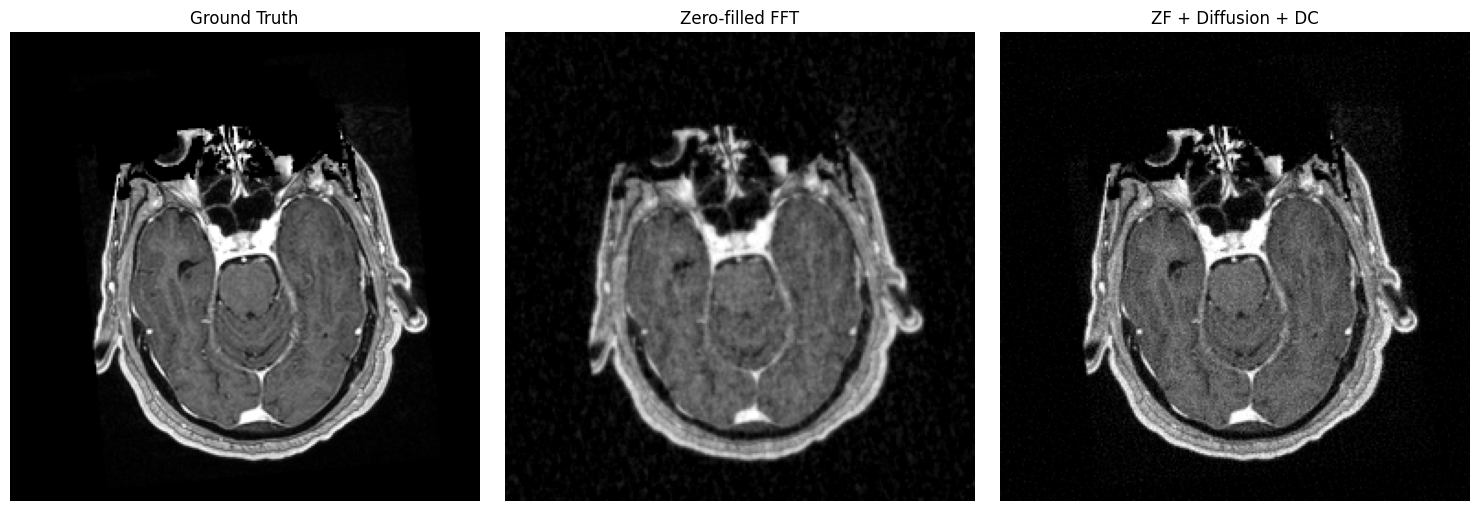

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(y_true_rep[0,0].detach().cpu(), cmap="gray")
axes[0].set_title("Ground Truth")
axes[0].axis("off")

axes[1].imshow(x_zf_rep[0,0].detach().cpu(), cmap="gray")
axes[1].set_title("Zero-filled FFT")
axes[1].axis("off")

axes[2].imshow(y_pred_rep_zf[0,0].detach().cpu(), cmap="gray")
axes[2].set_title("ZF + Diffusion + DC")
axes[2].axis("off")

plt.tight_layout()
plt.show()